In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import matplotx
from sklearn.preprocessing import MinMaxScaler

plt.style.use(matplotx.styles.tokyo_night['night'])

In [2]:
fav = pd.read_csv("Output/niq_iq_trends.csv")
fav.columns

Index(['country', 'iso3', 'year', 'IQ', 'test_type', 'n_individuals',
       'domain'],
      dtype='object')

In [3]:
fav[fav['country'] == 'India']

,country,iso3,year,IQ,test_type,n_individuals,domain
194,India,IND,1968,67.047906,RPM,300.00,1.0
195,India,IND,1984,78.022083,RPM,100.00,1.0
196,India,IND,1988,85.040000,WIS,390.00,2.0
197,India,IND,1988,69.940000,WIS,358.00,2.0
198,India,IND,1993,82.541794,RPM,39.00,1.0
199,India,IND,1994,65.436669,RPM,252.00,1.0
200,India,IND,1994,78.395123,RPM,360.00,1.0
201,India,IND,1994,68.077732,RPM,290.00,1.0
202,India,IND,1997,88.699310,RPM,2248.00,1.0
203,India,IND,1997,84.644519,RPM,8609.00,1.0


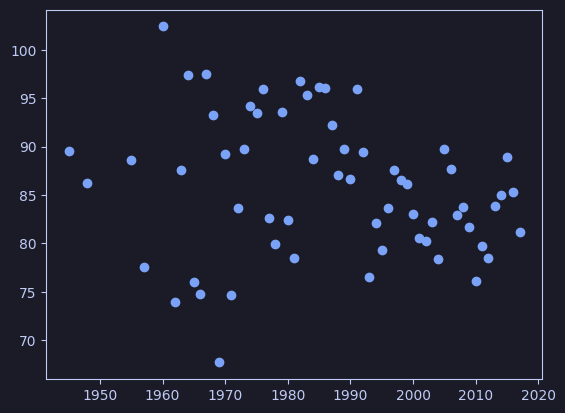

In [19]:
stuff = dict(zip(fav['year'].unique(), [fav[fav['year'] == y]['IQ'].mean() for y in fav['year'].unique()]))
plt.scatter(list(stuff.keys()), list(stuff.values()))

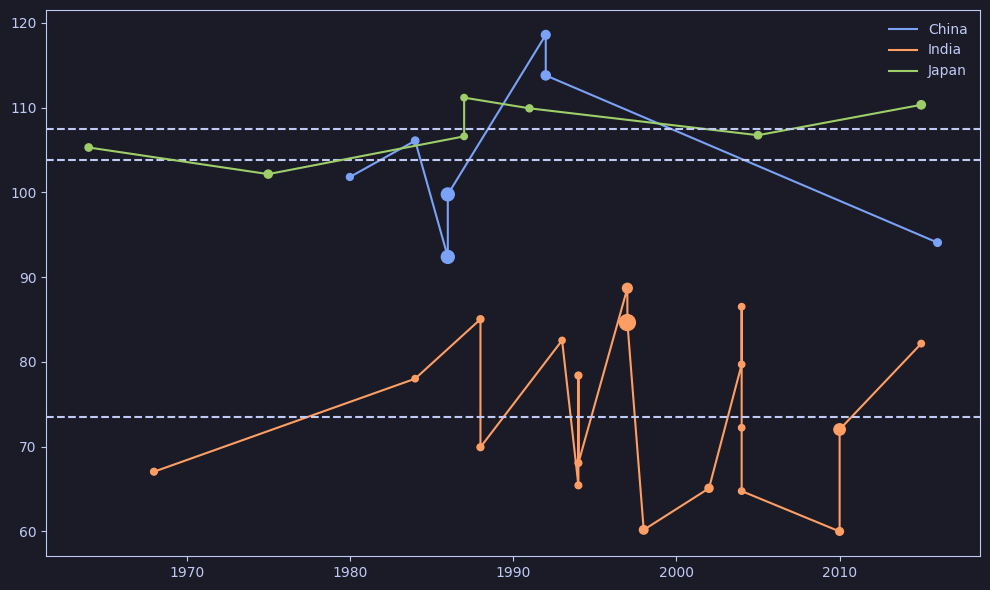

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# normalize n_individuals per country to use as scatter point size
scaler = MinMaxScaler(feature_range=(20, 200))
fav['n_norm'] = scaler.fit_transform(fav[['n_individuals']])

countries = ['China', 'India', 'Japan']

for c in countries:
    ax.plot(fav[fav['country'] == c]['year'], fav[fav['country'] == c]['IQ'], label = c)
    ax.scatter(x=fav[fav['country'] == c]['year'], y=fav[fav['country'] == c]['IQ'], s=fav[fav['country'] == c]['n_norm'])
    ax.axhline(y=fav[fav['country'] == c]['IQ'].mean(), linestyle='--')

ax.legend()
fig.tight_layout()

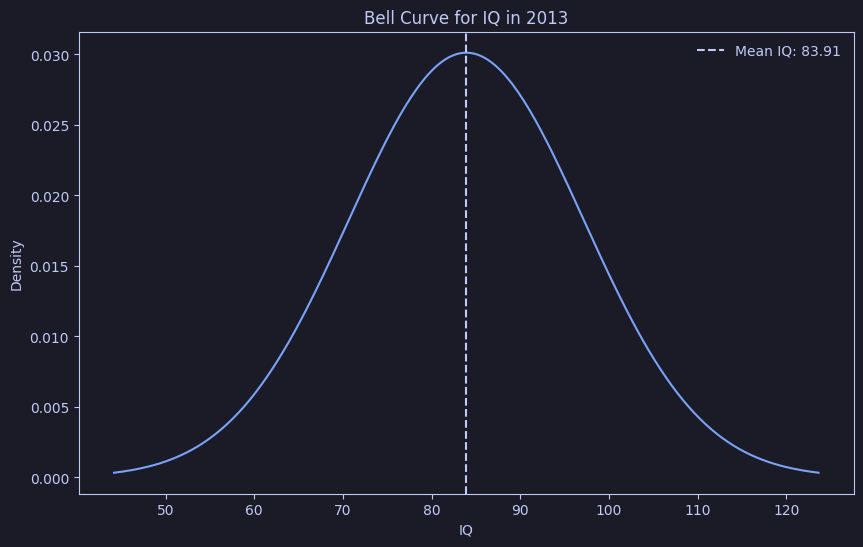

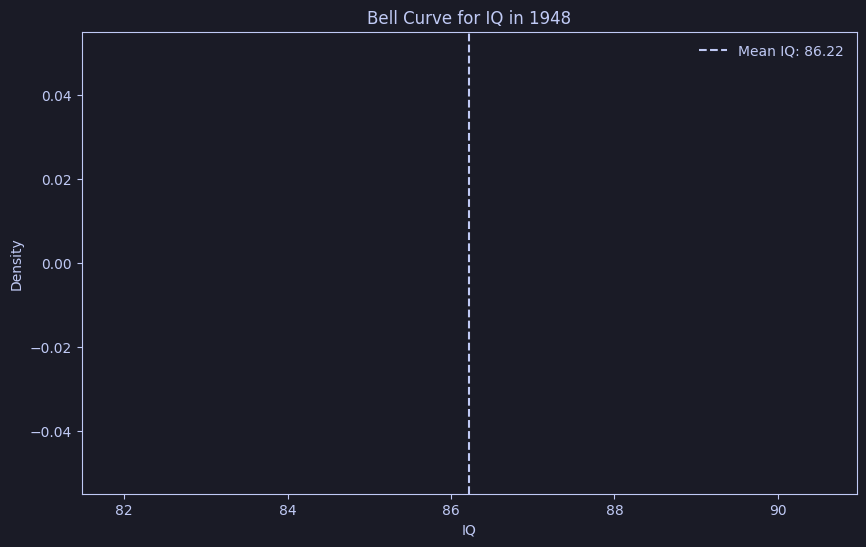

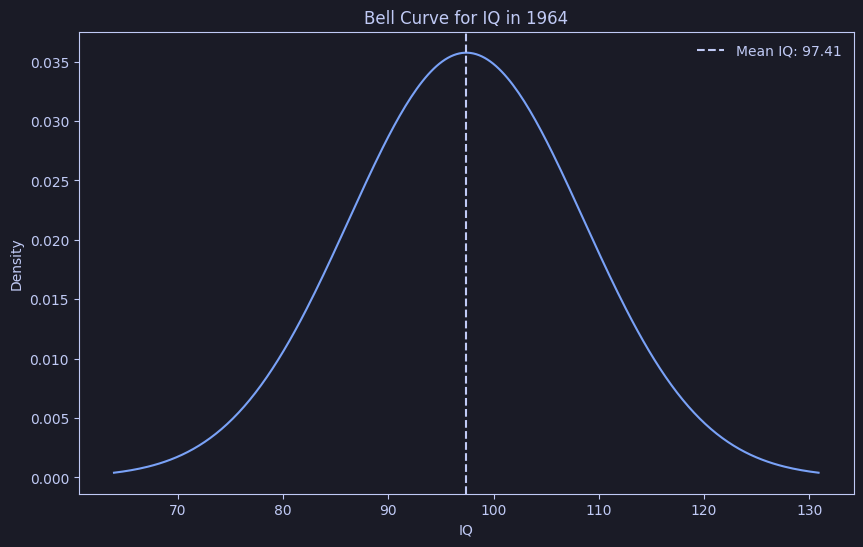

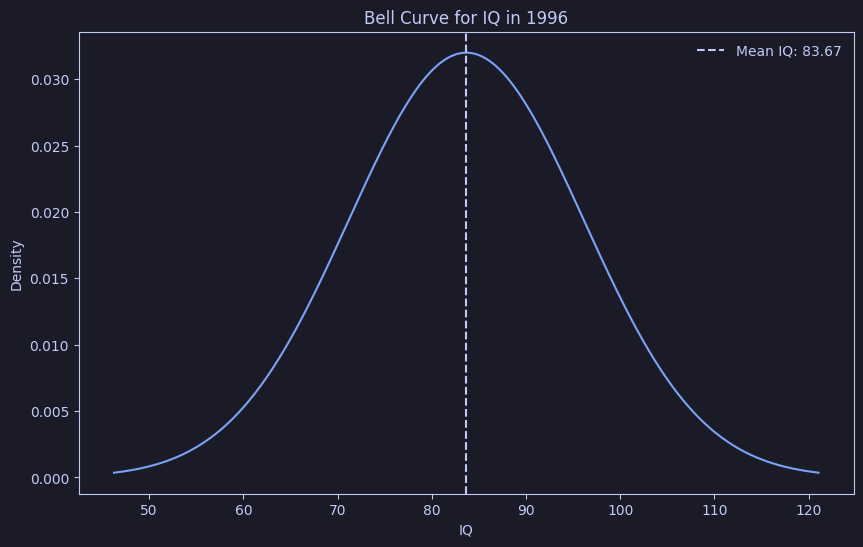

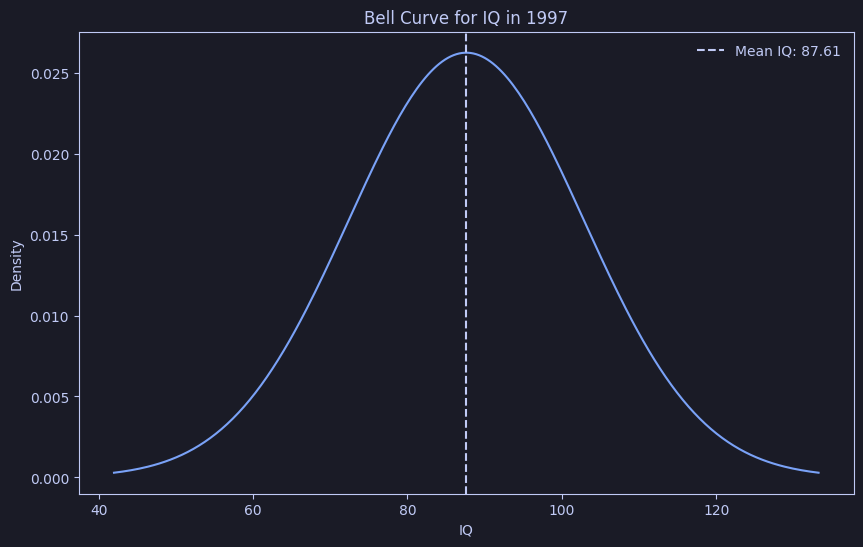

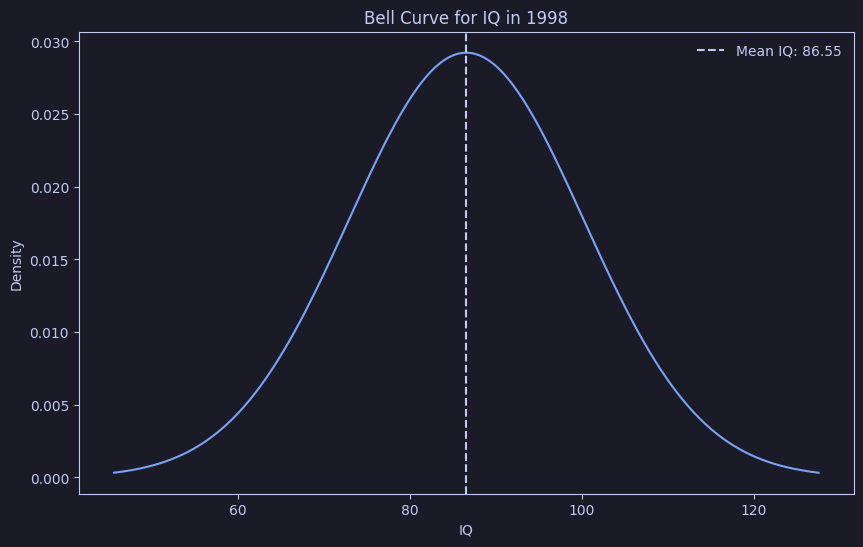

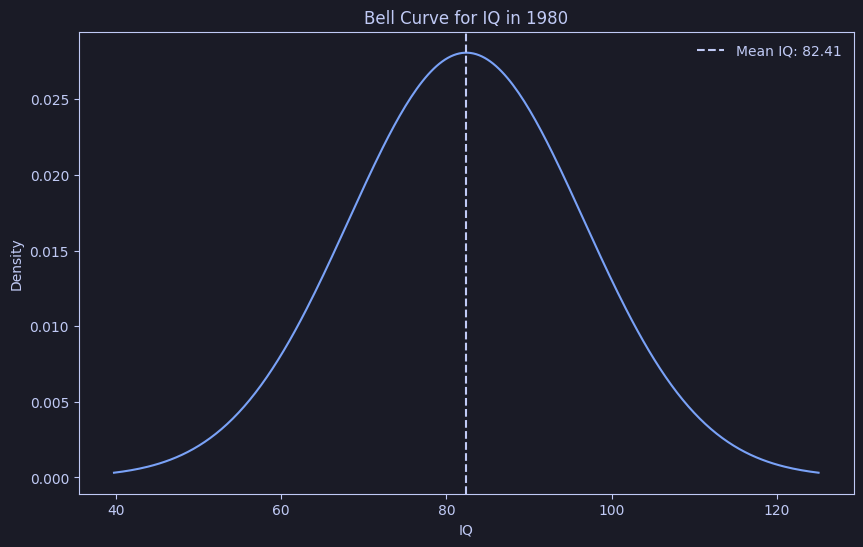

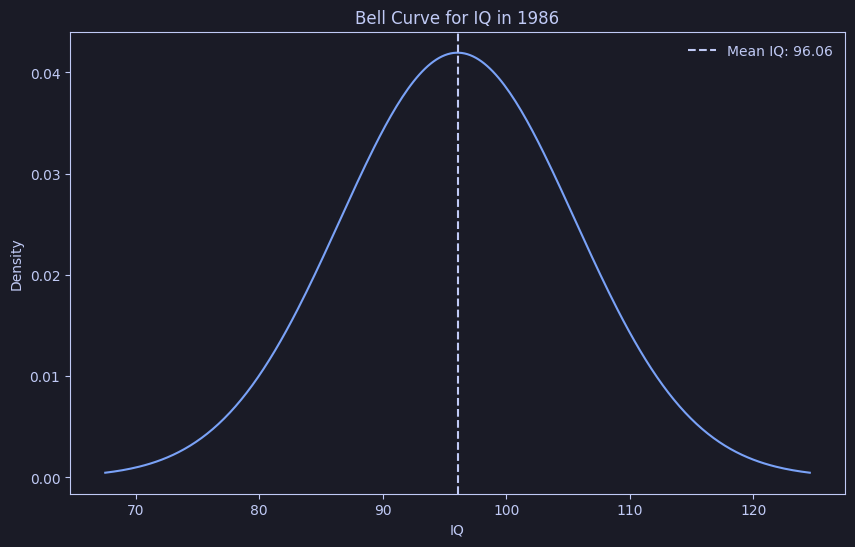

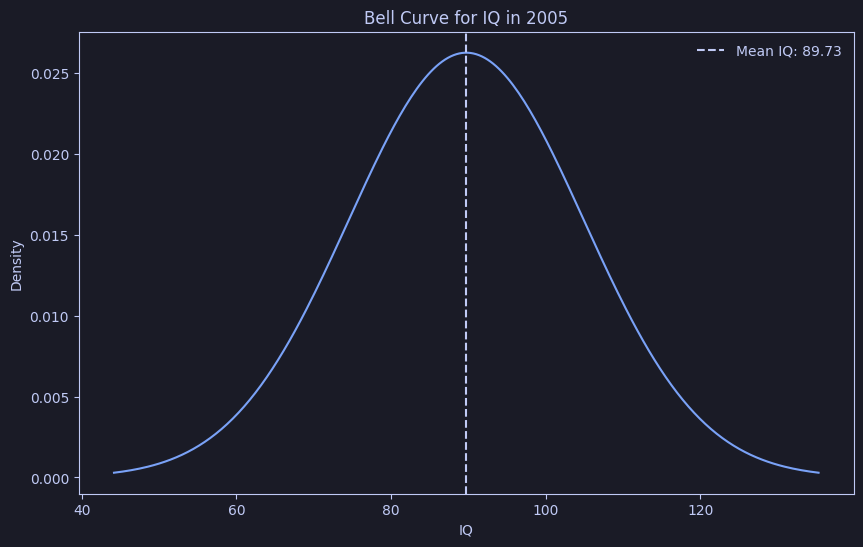

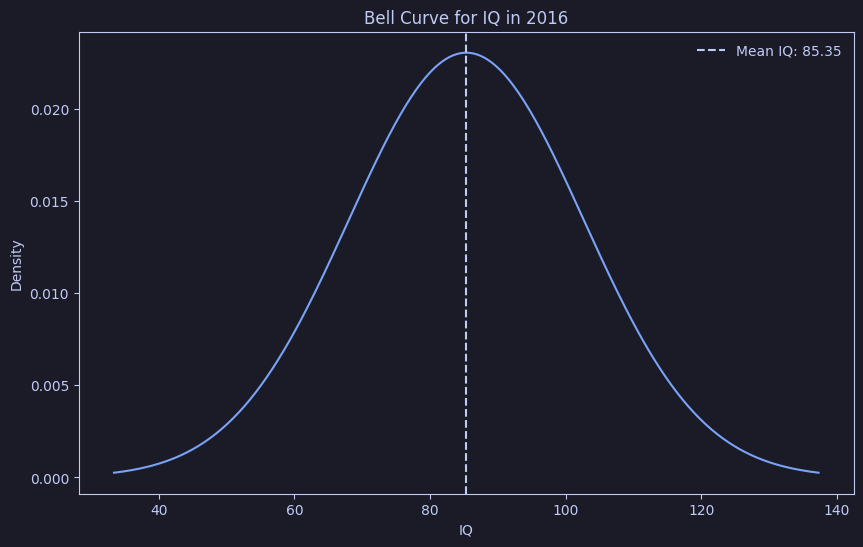

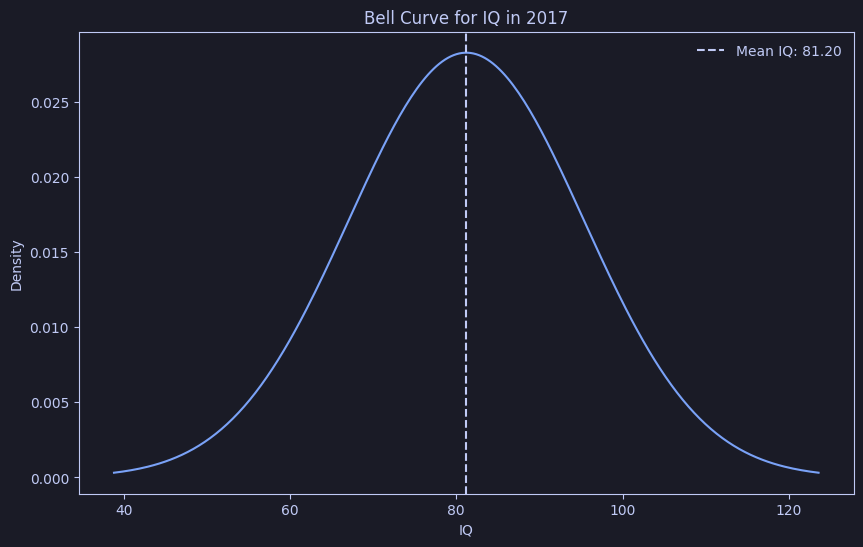

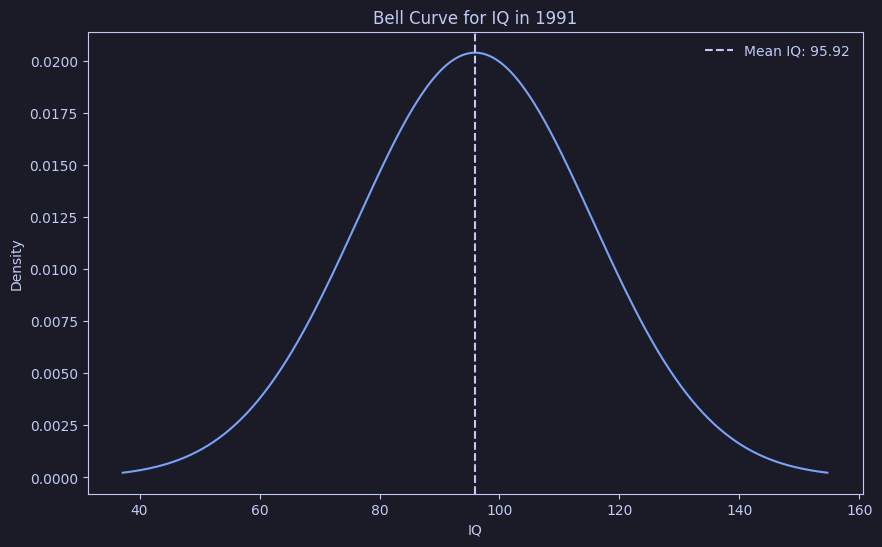

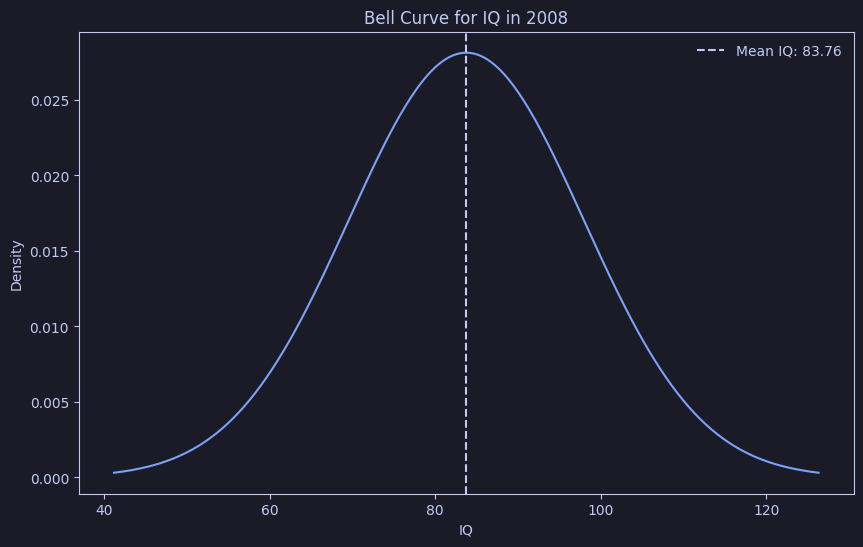

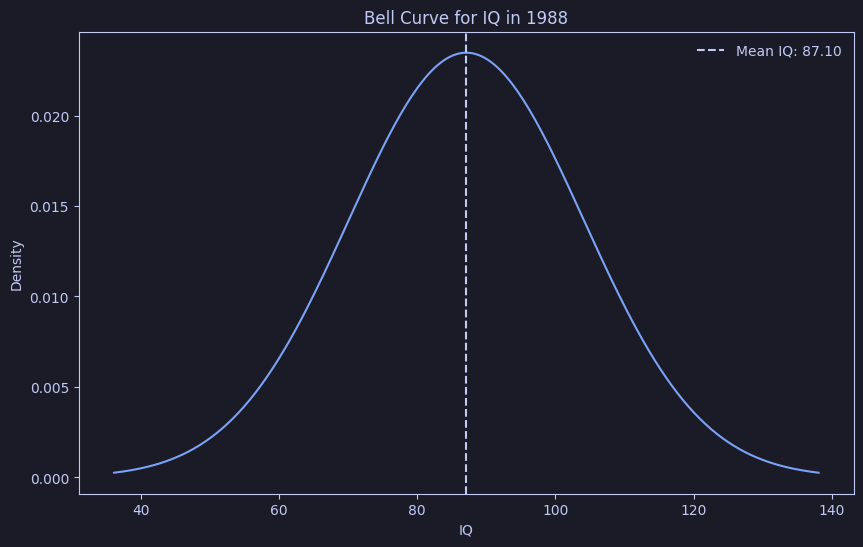

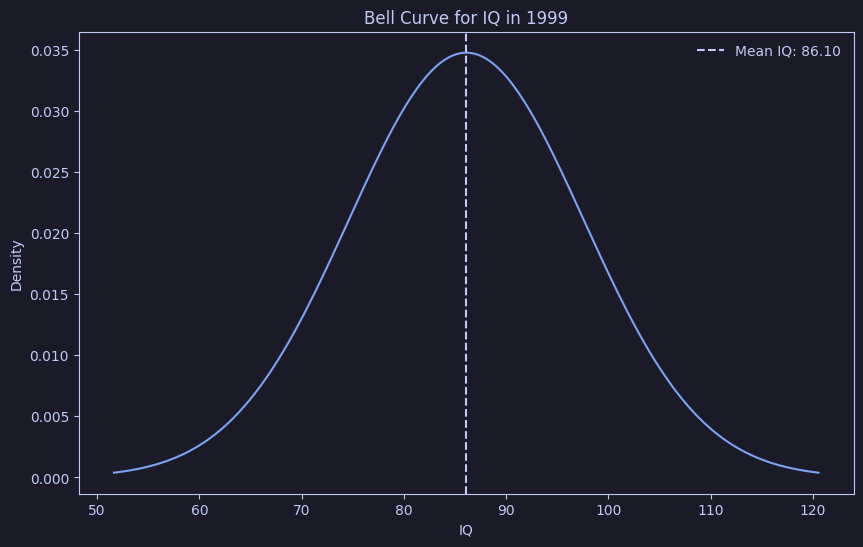

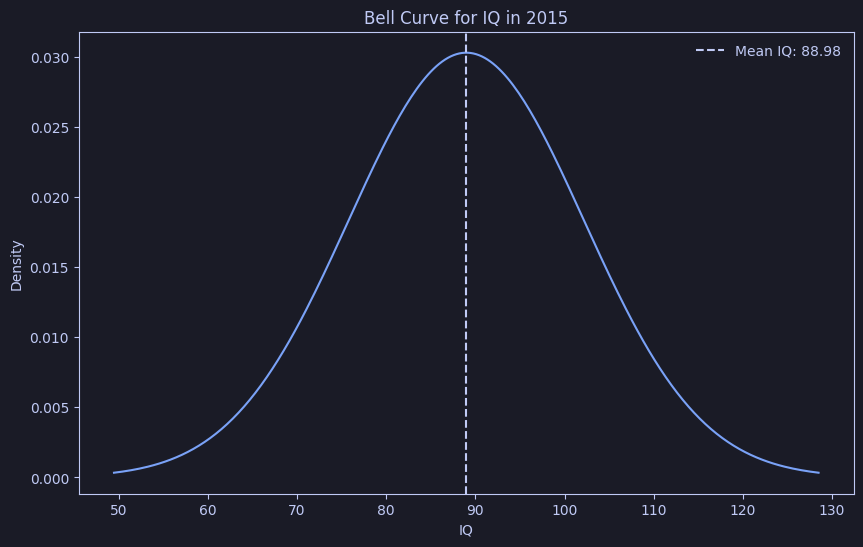

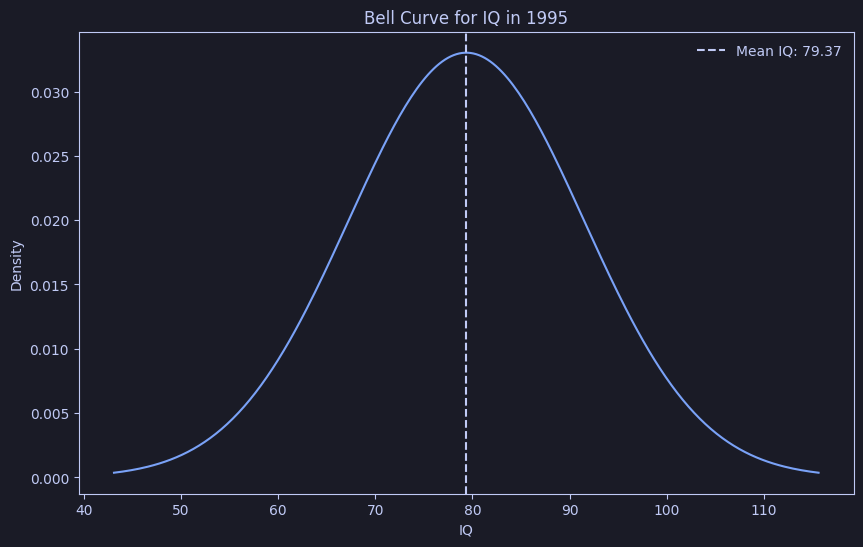

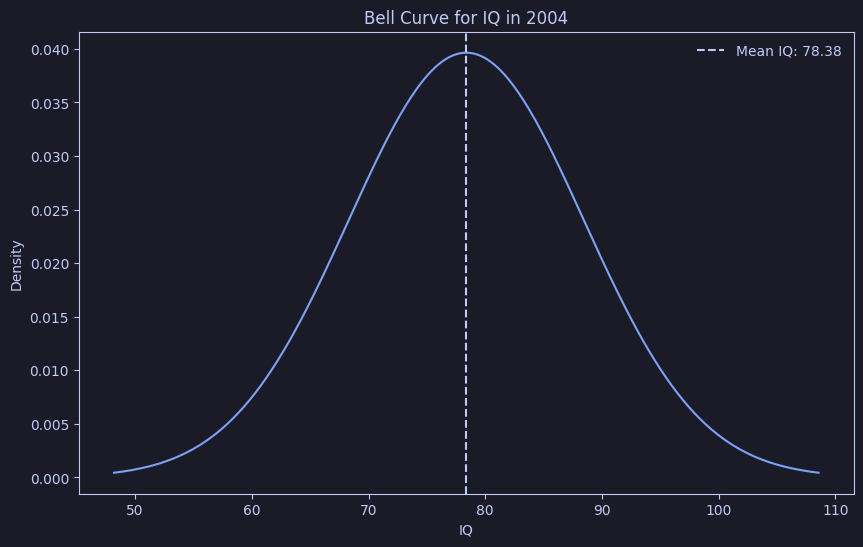

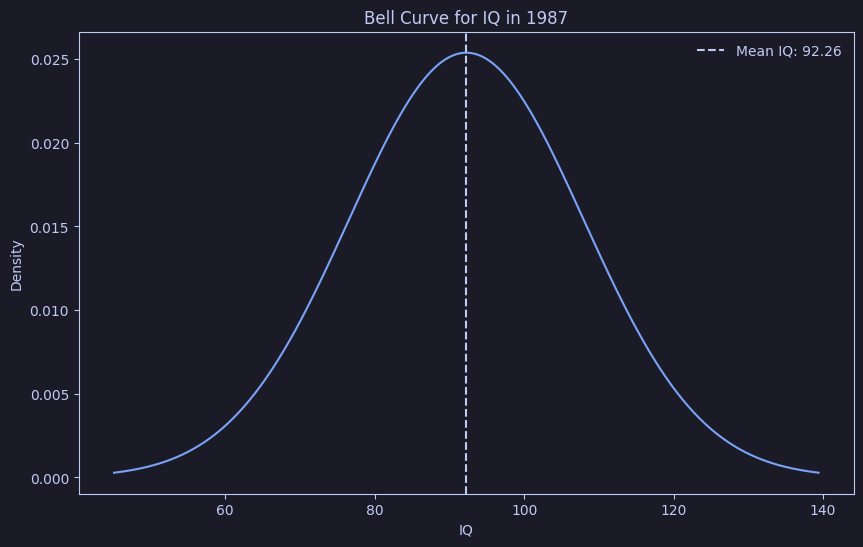

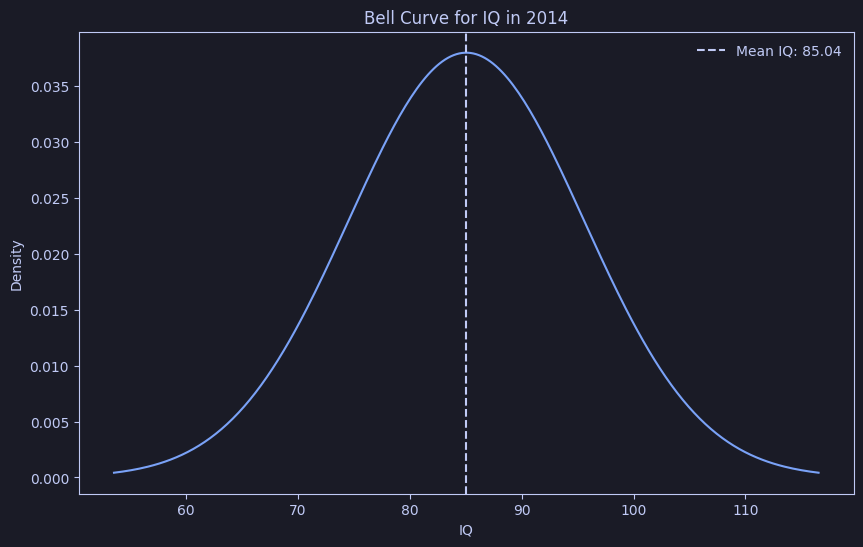

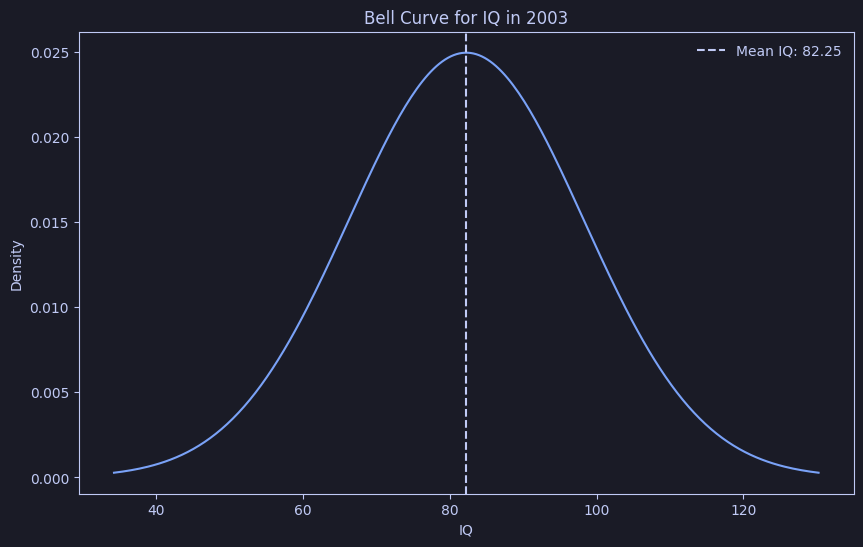

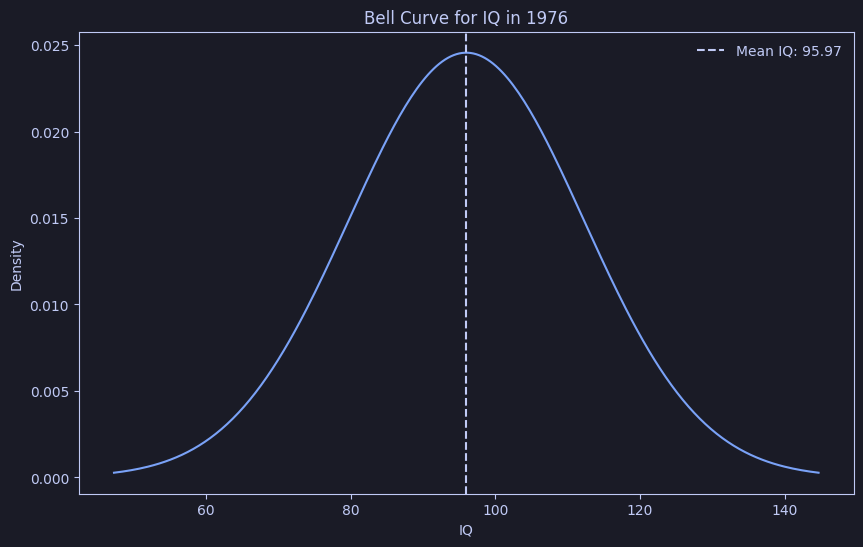

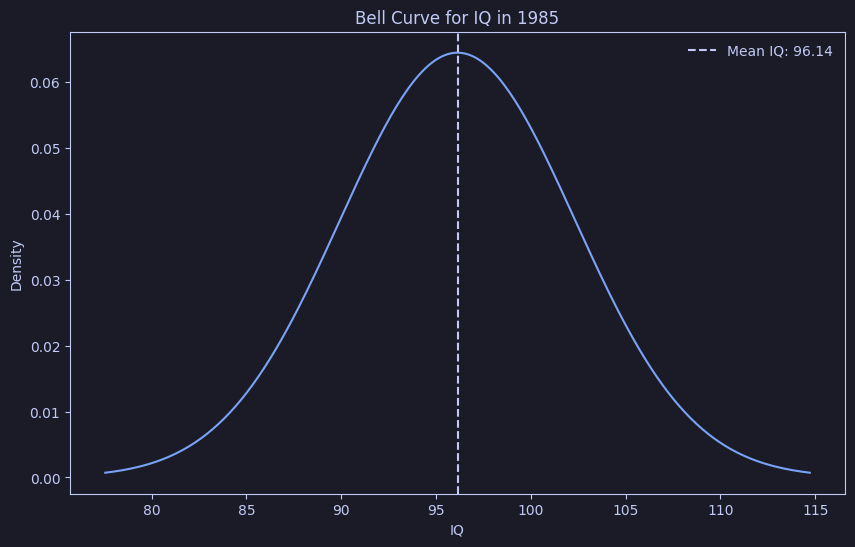

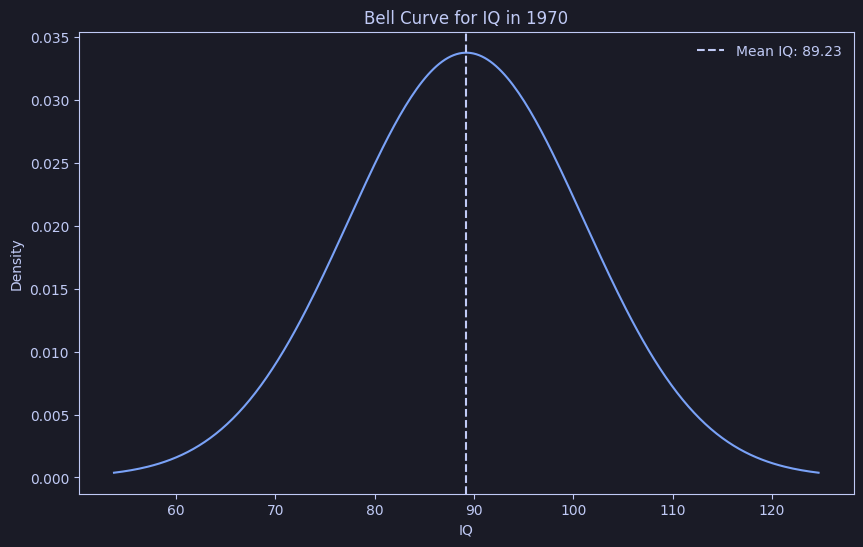

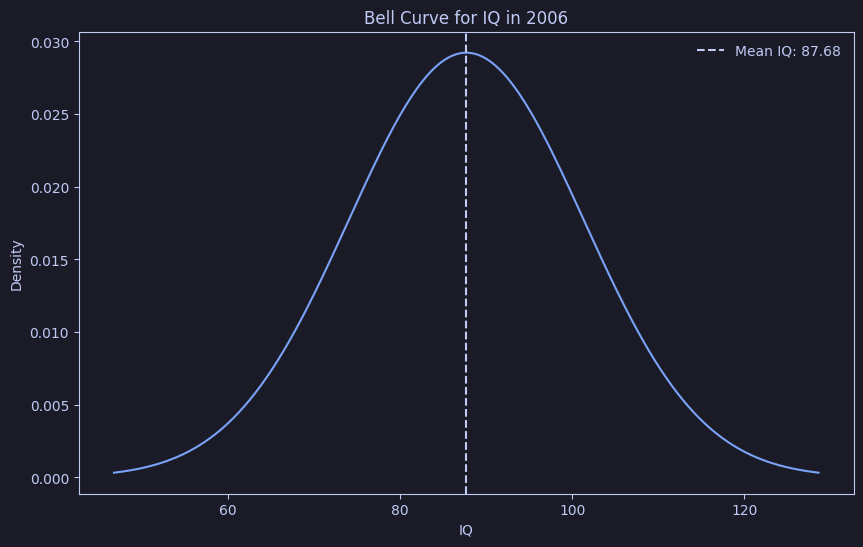

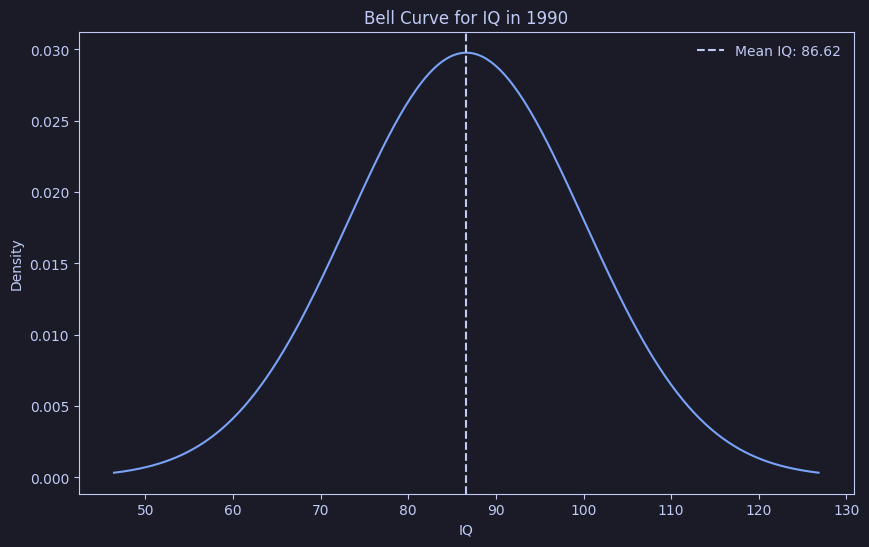

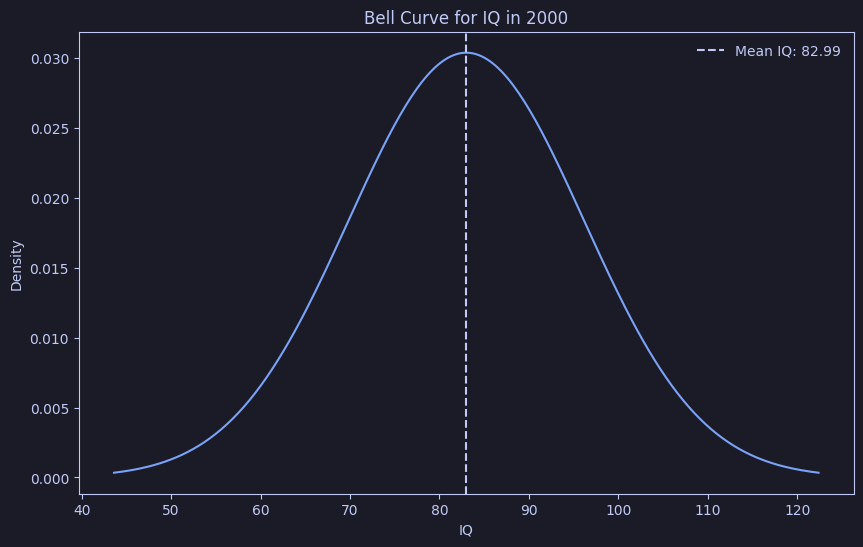

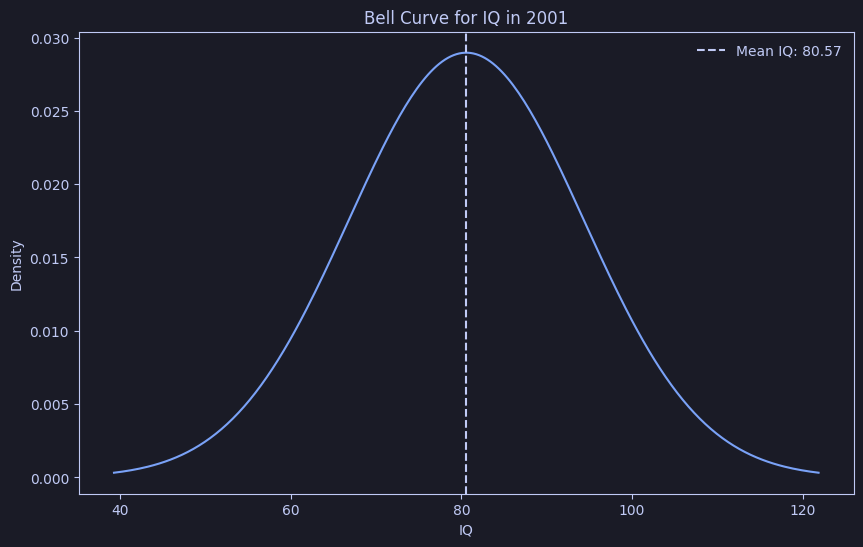

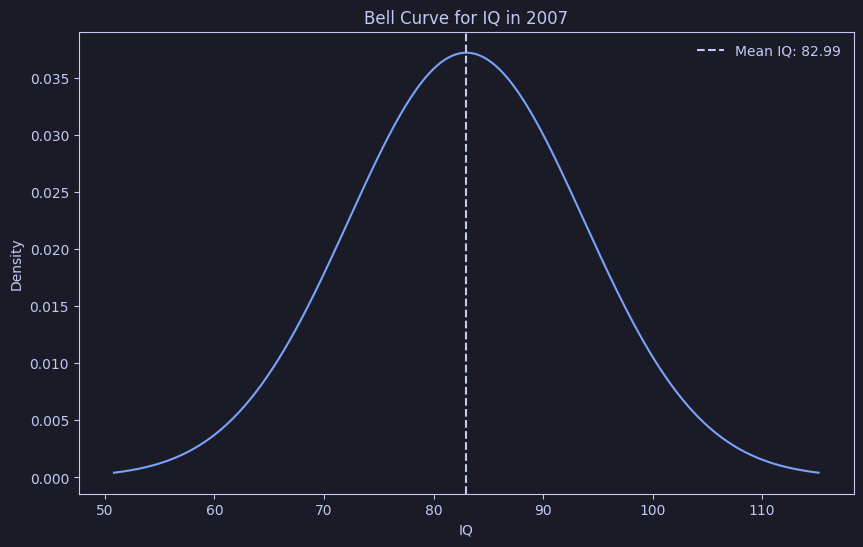

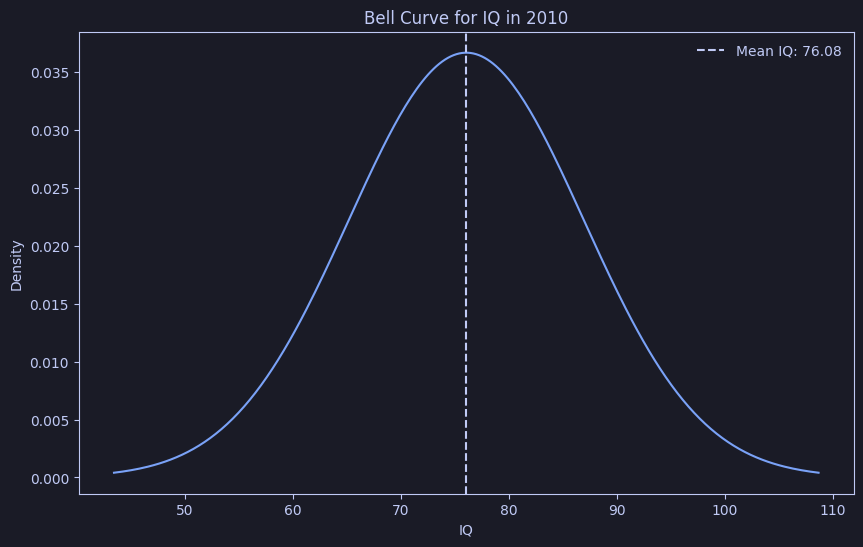

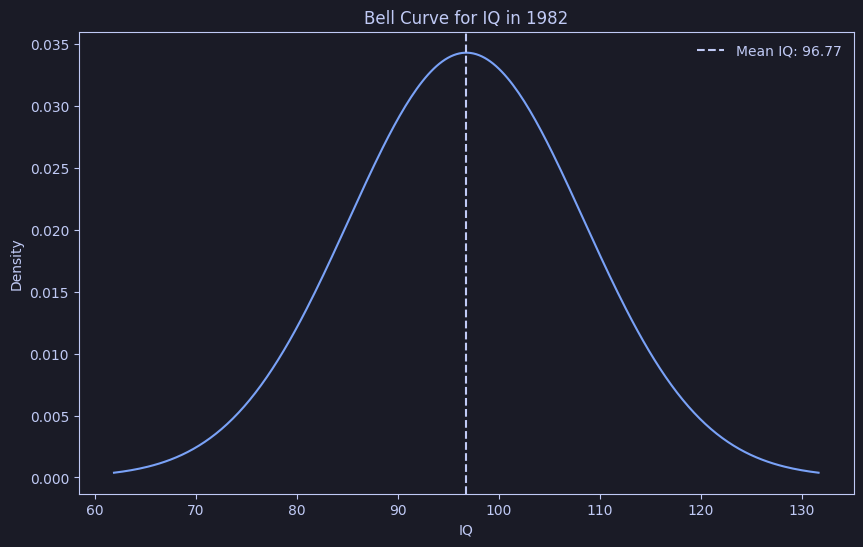

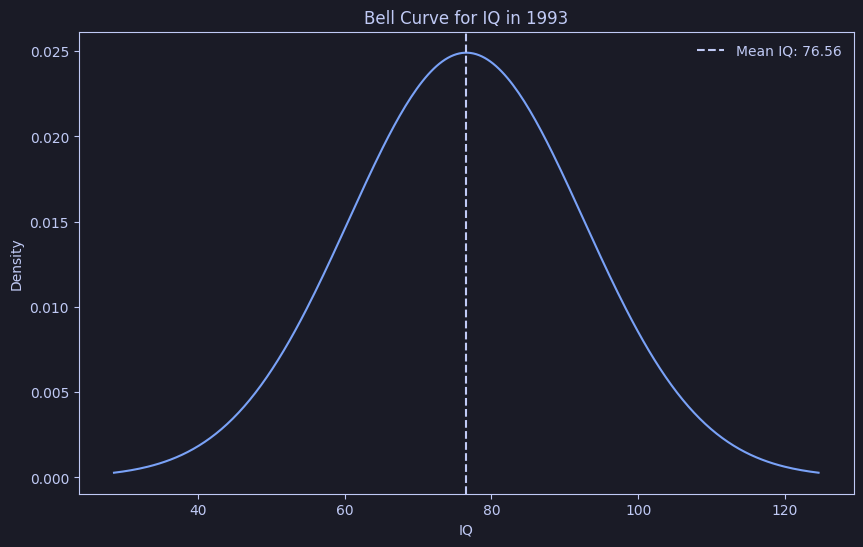

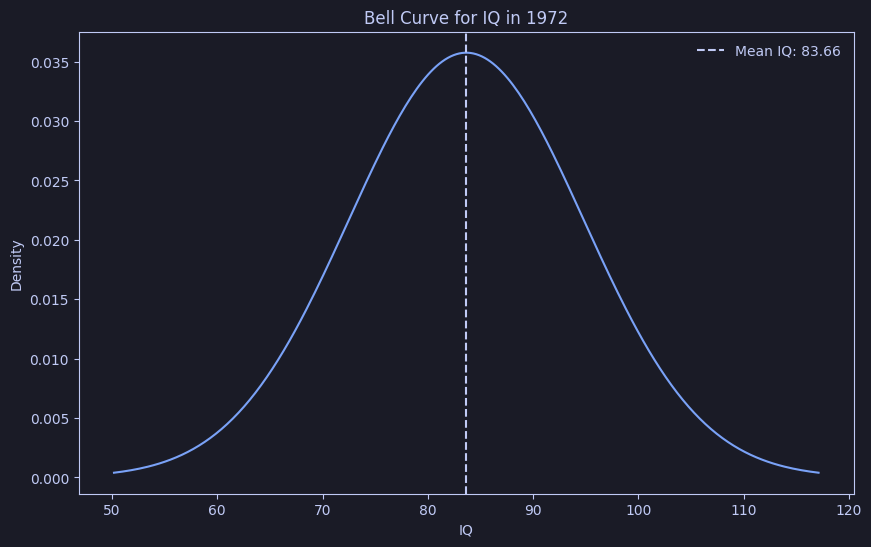

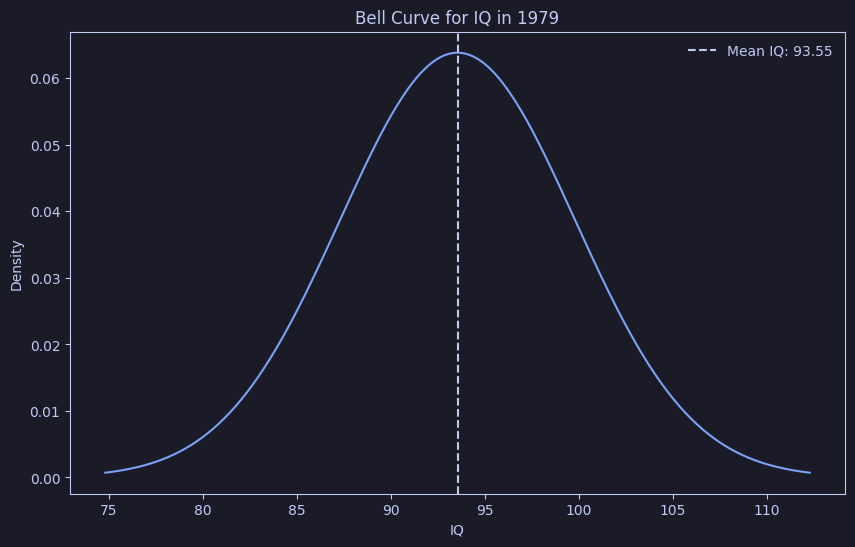

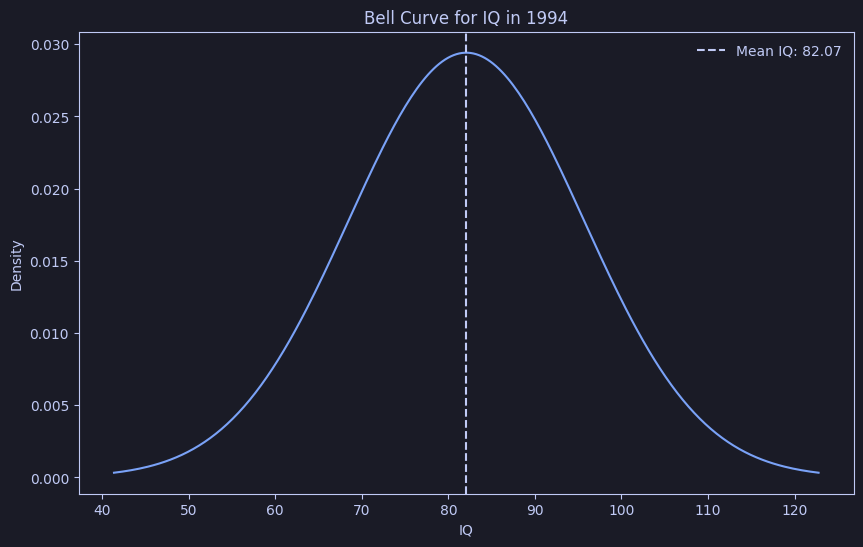

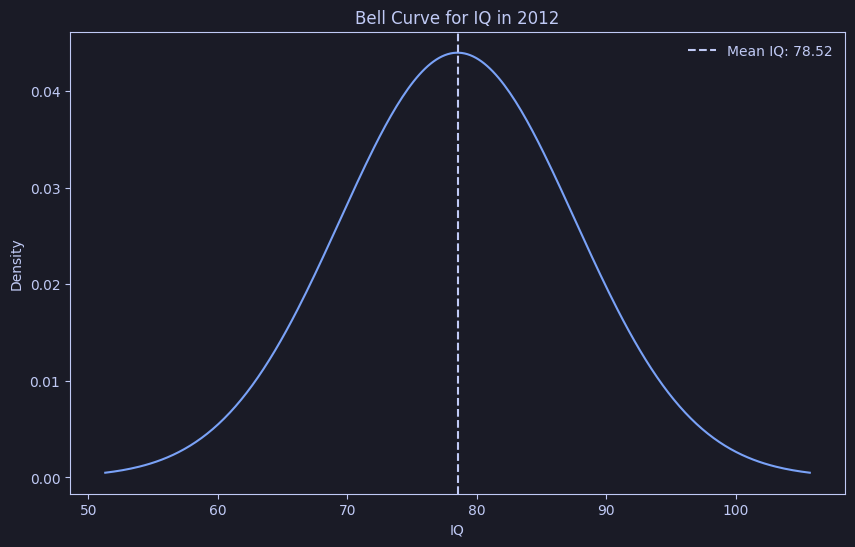

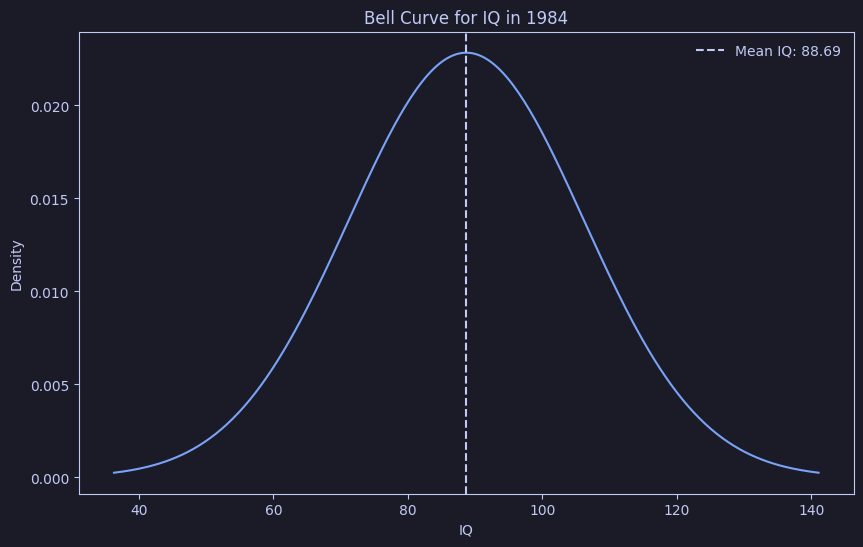

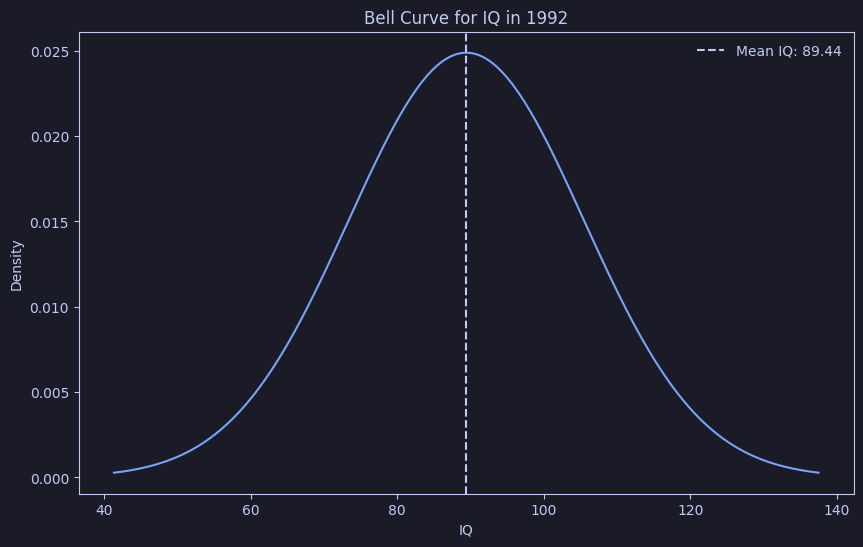

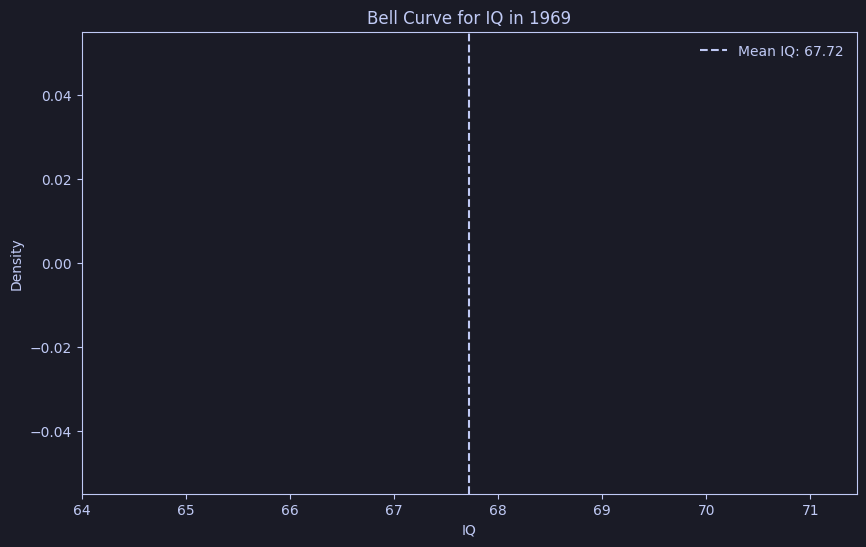

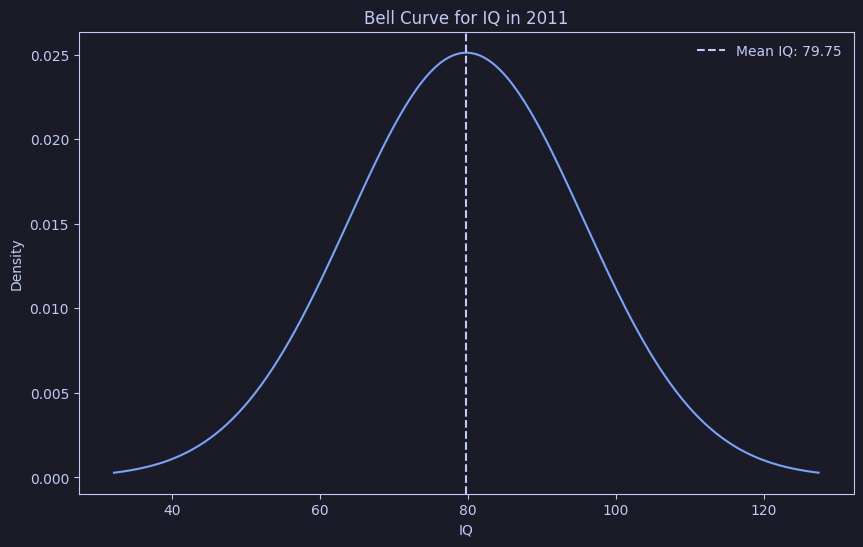

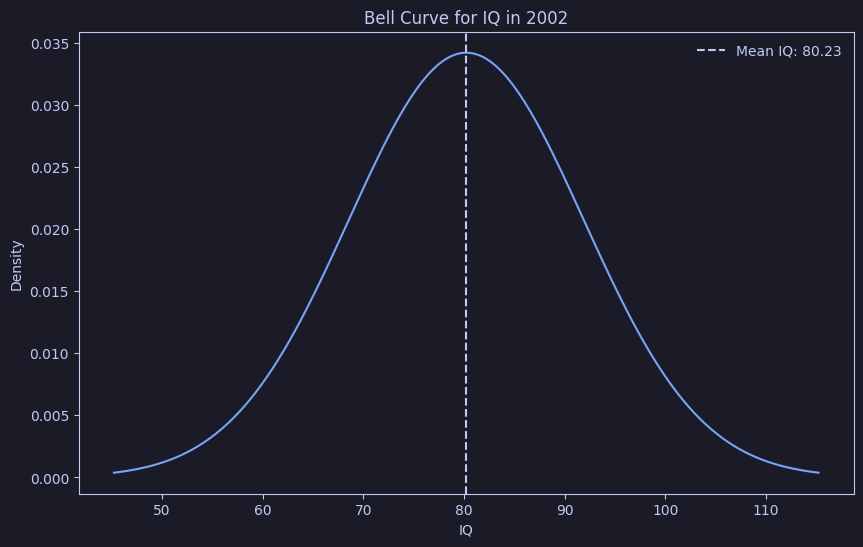

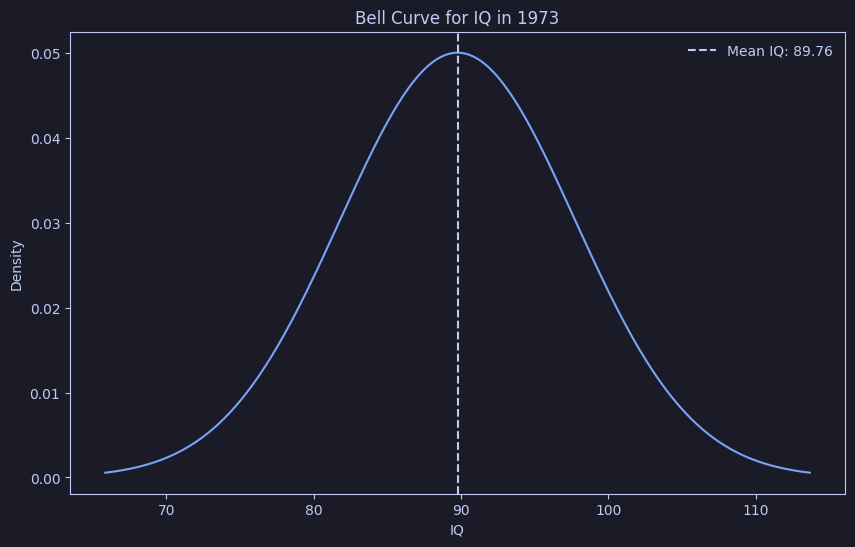

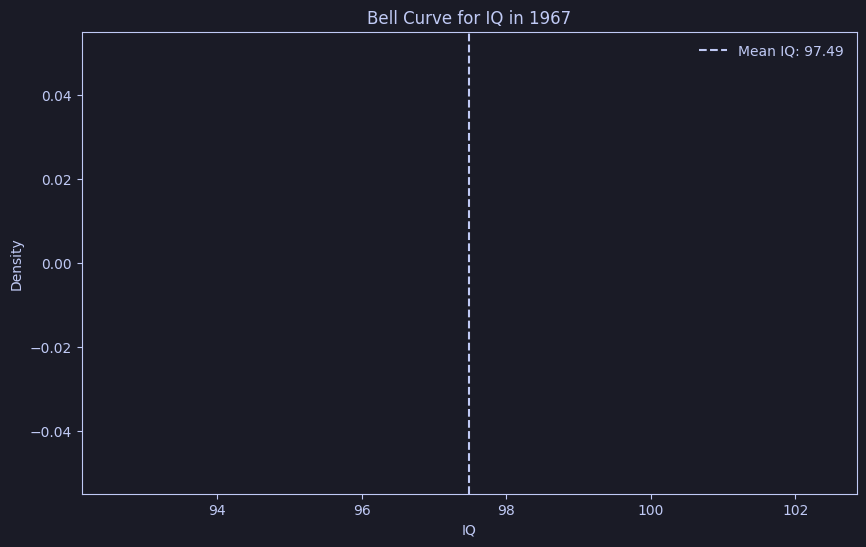

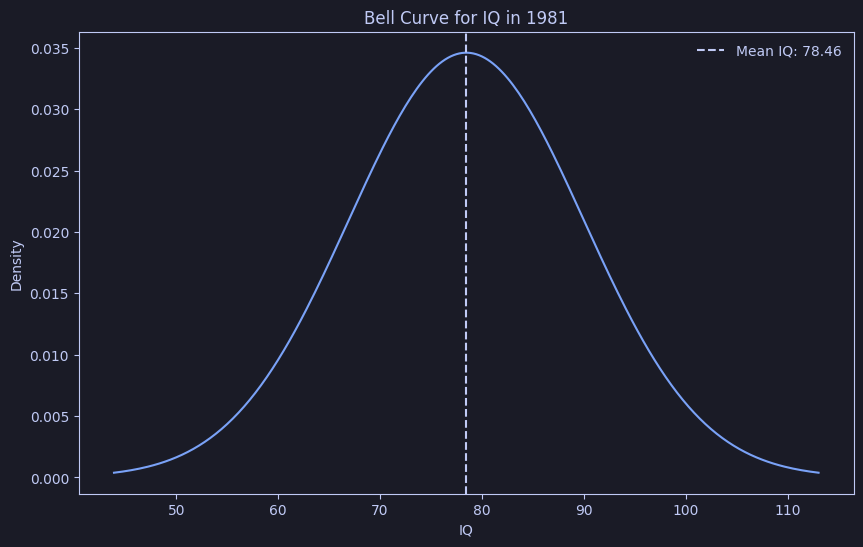

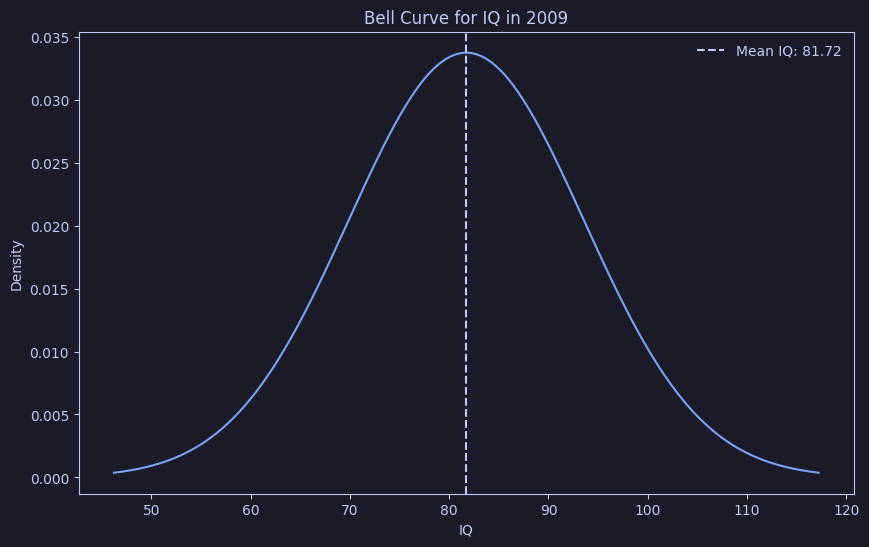

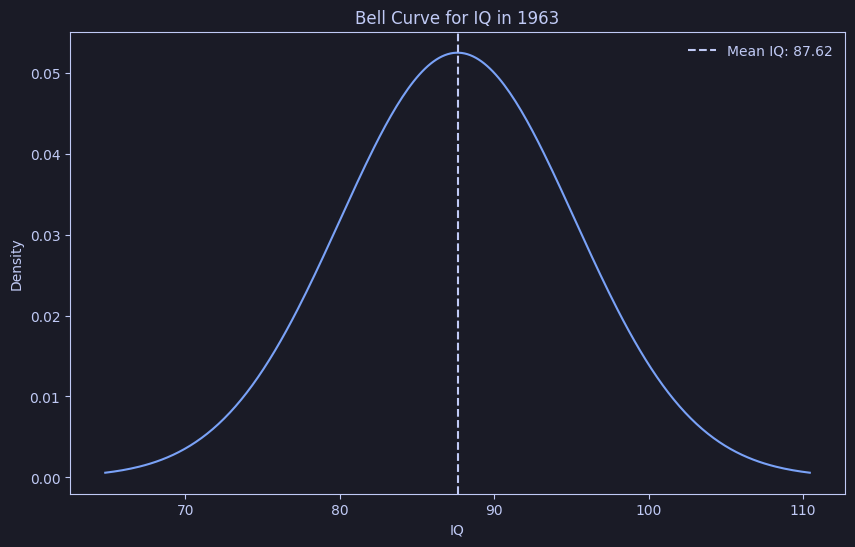

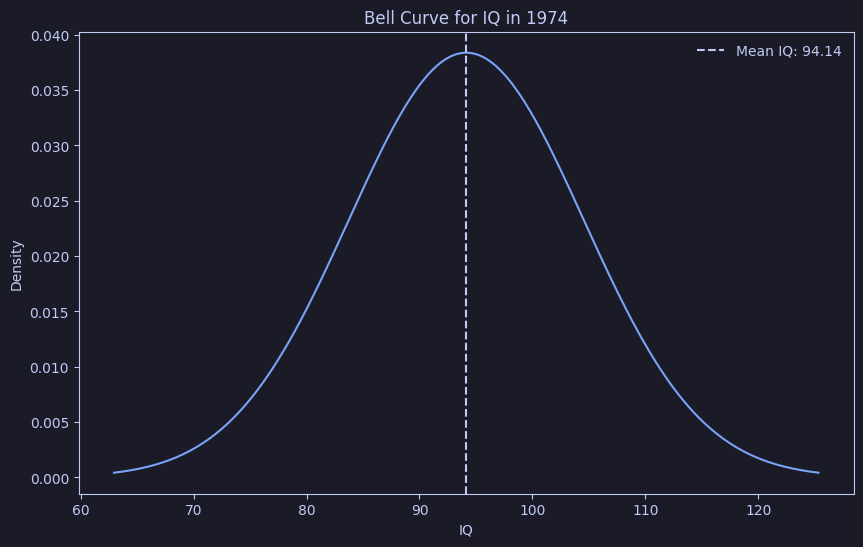

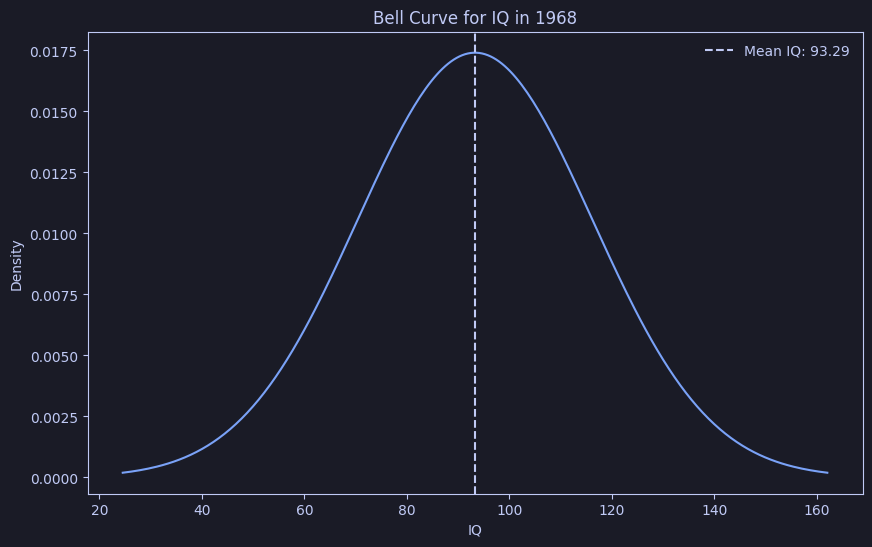

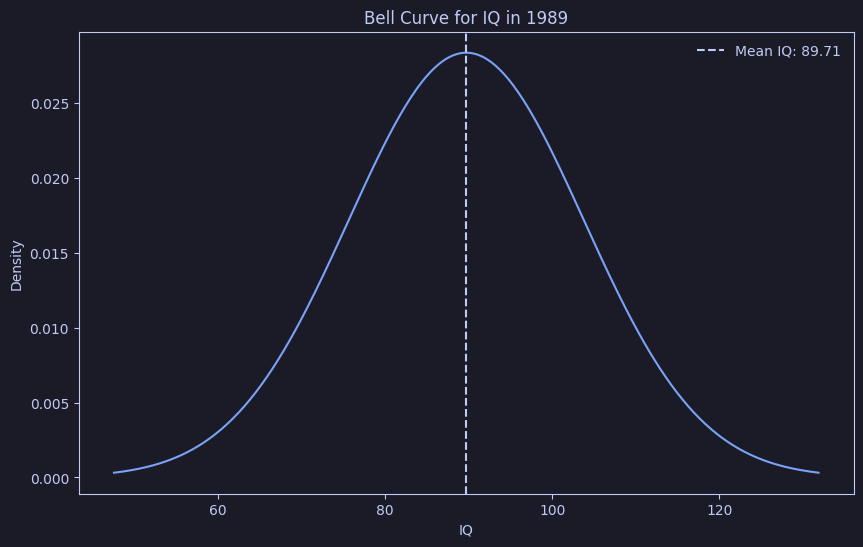

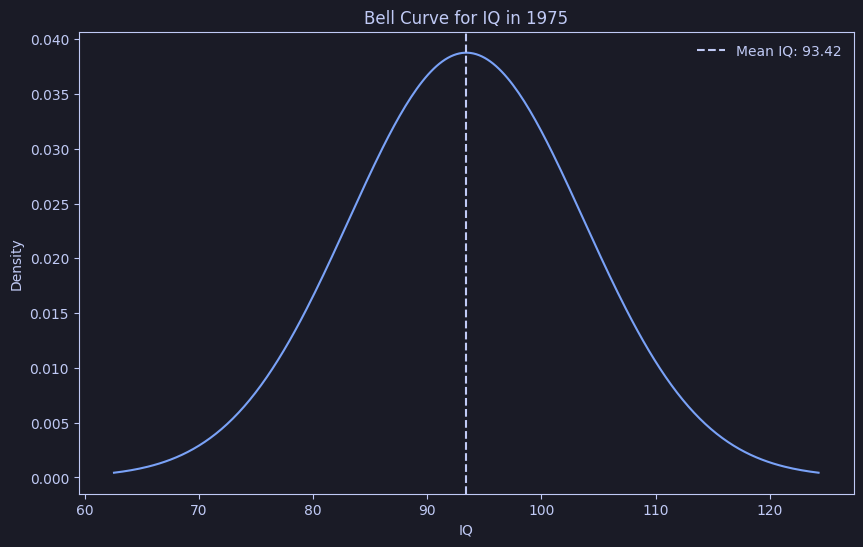

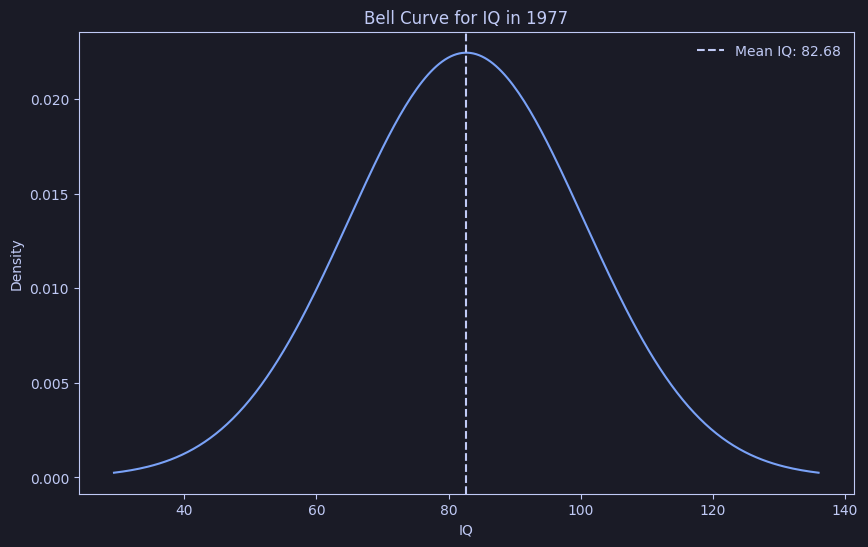

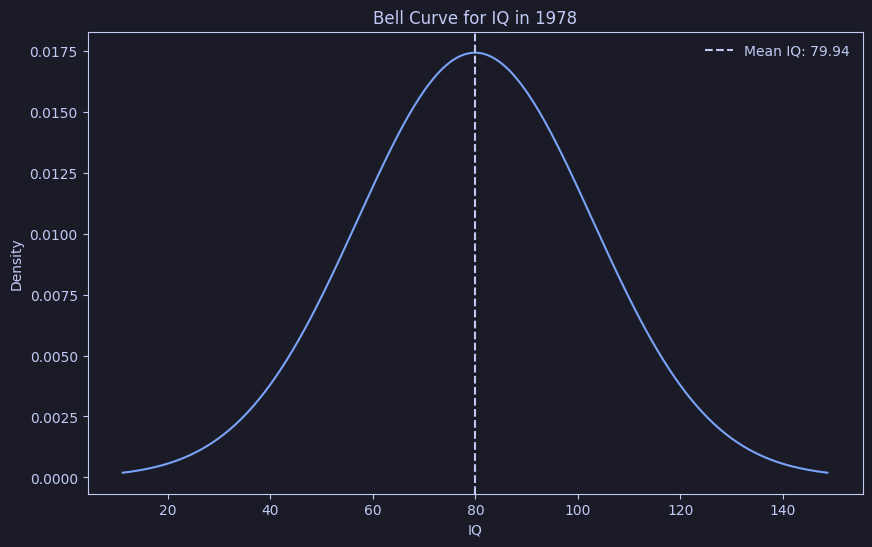

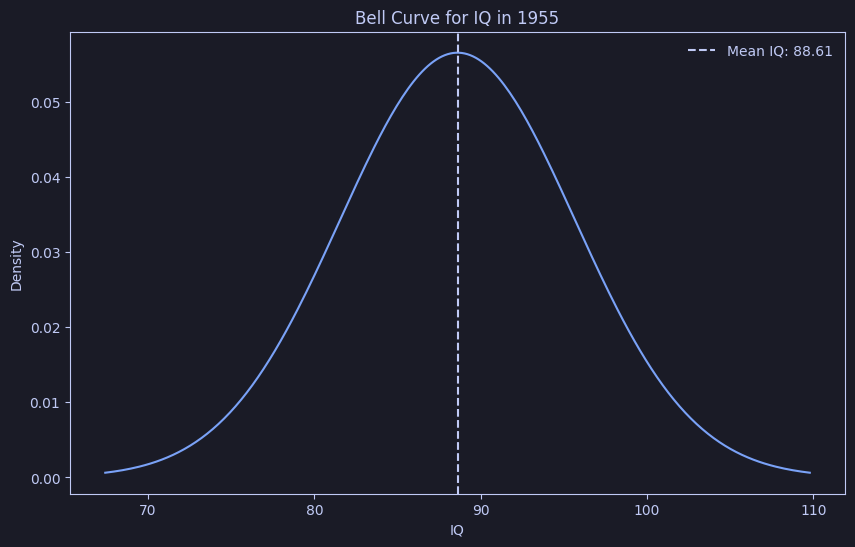

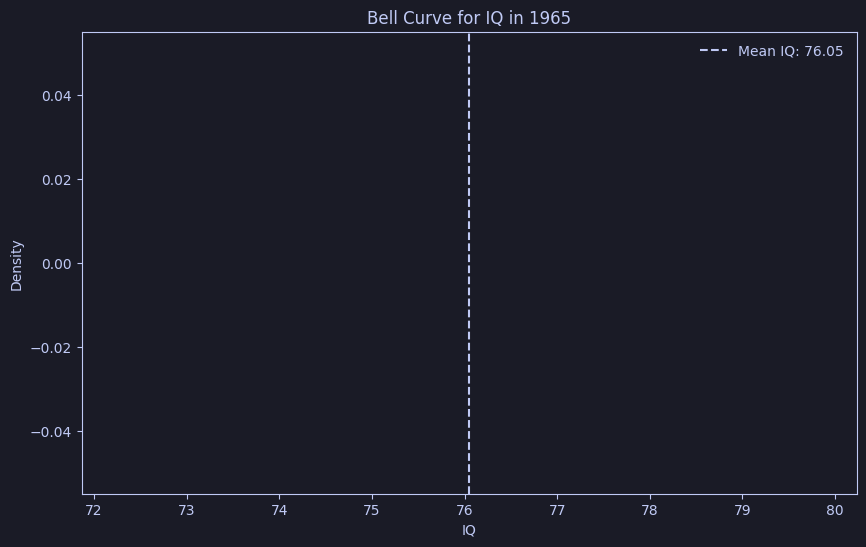

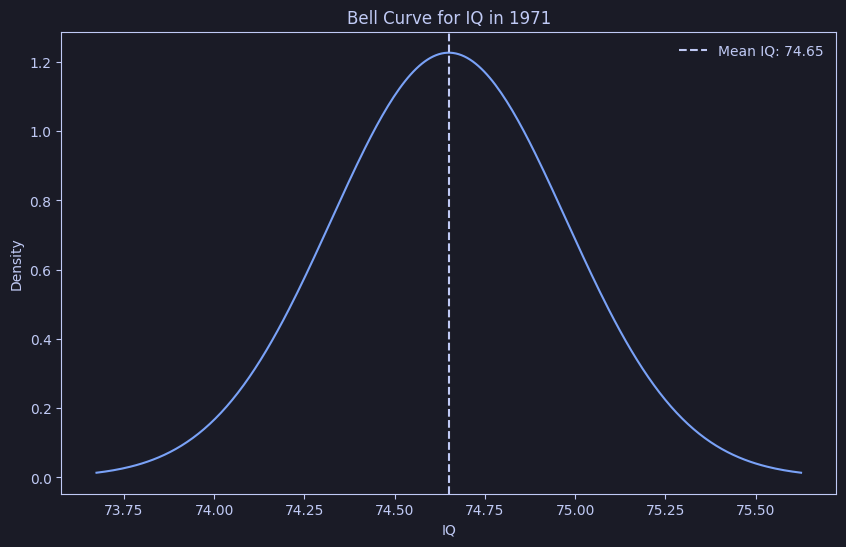

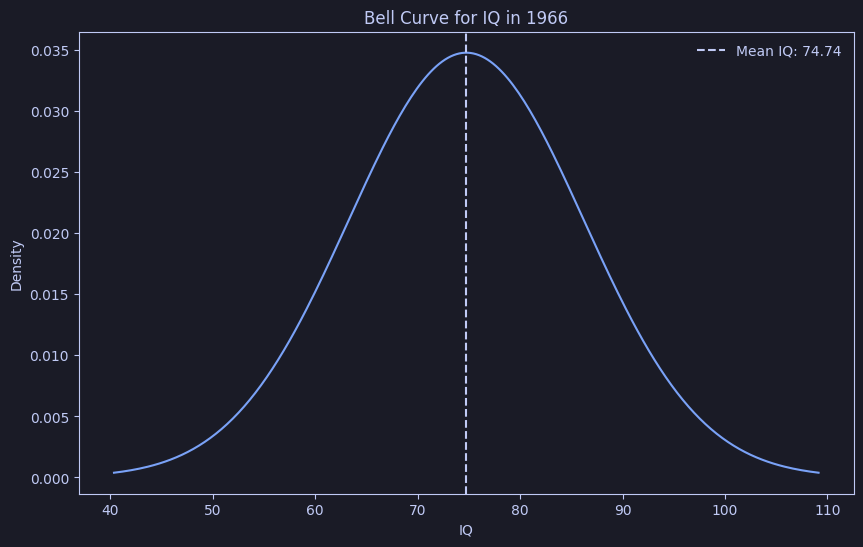

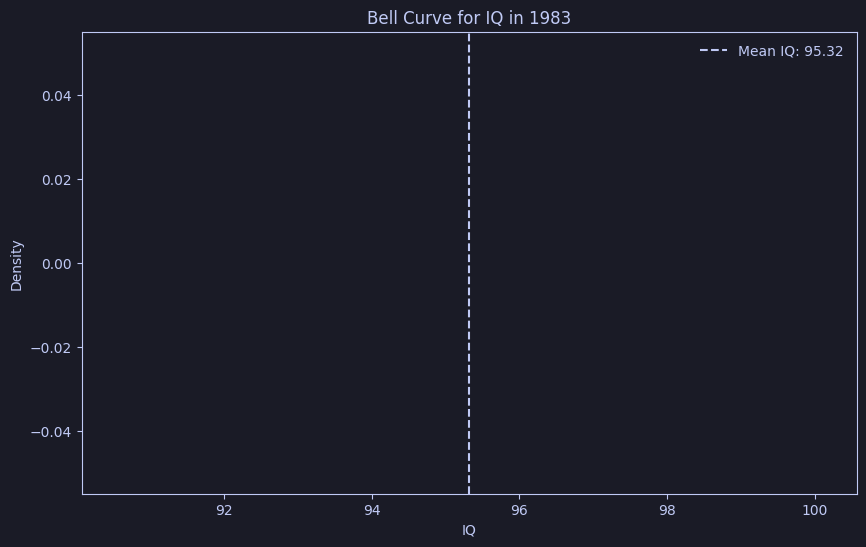

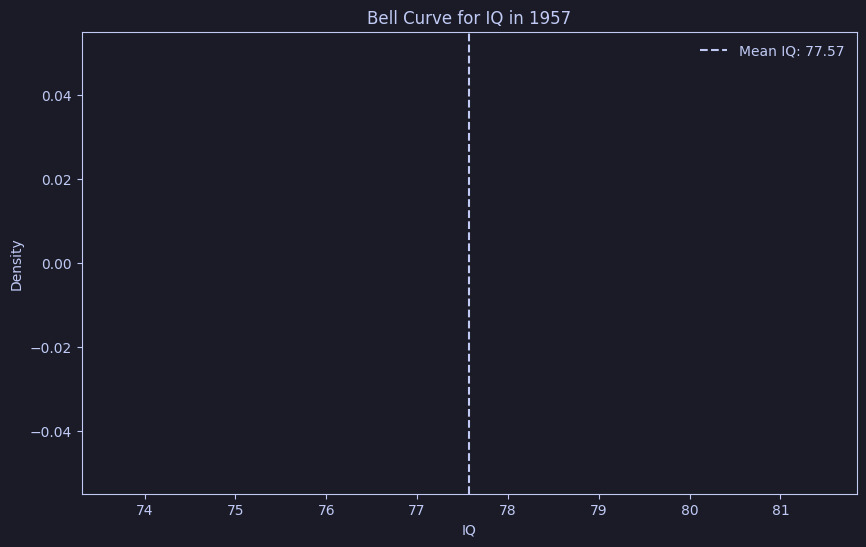

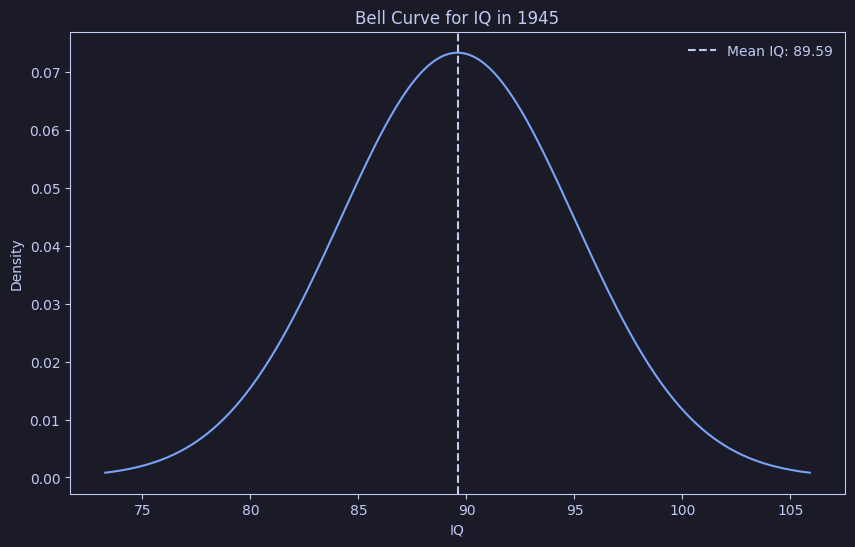

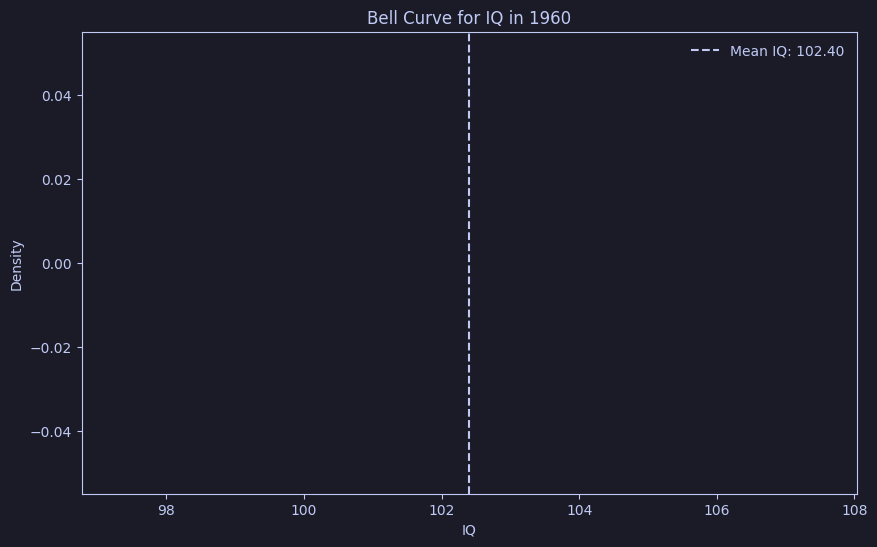

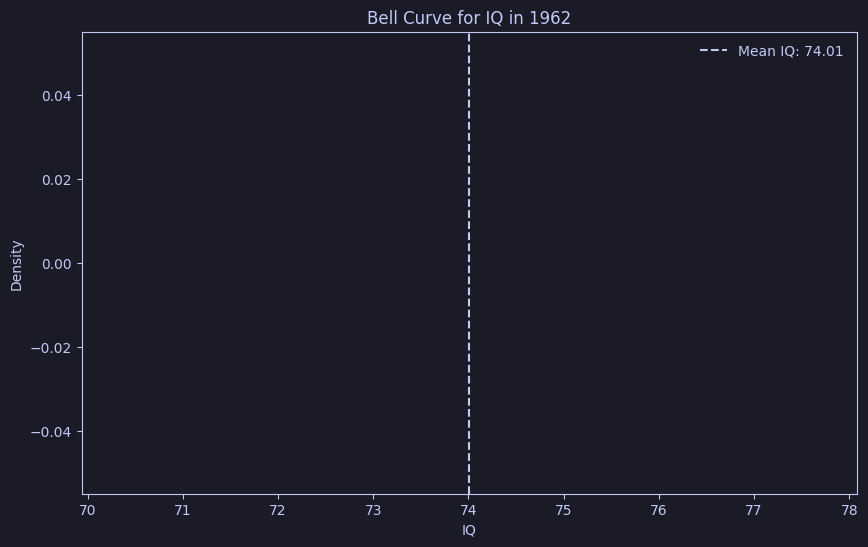

In [27]:
# plot bell curve for each year
for year in fav['year'].unique():
    plt.figure(figsize=(10, 6))
    data = fav[fav['year'] == year]['IQ']
    mean = data.mean()
    std = data.std()
    x = np.linspace(mean - 3*std, mean + 3*std, 250)
    y = stats.norm.pdf(x, mean, std)
    plt.plot(x, y)
    plt.title(f'Bell Curve for IQ in {year}')
    plt.axvline(x=mean, linestyle='--', label=f'Mean IQ: {mean:.2f}')
    plt.xlabel('IQ')
    plt.ylabel('Density')
    plt.legend()
    plt.show()